In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, roc_auc_score

file_path = 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

# Carregando cada aba em um DataFrame separado
df_2022 = pd.read_excel(file_path, sheet_name='PEDE2022')
df_2023 = pd.read_excel(file_path, sheet_name='PEDE2023')
df_2024 = pd.read_excel(file_path, sheet_name='PEDE2024')

# Exemplo: verificando se carregou corretamente
print(f"Linhas em 2022: {len(df_2022)}")
print(f"Linhas em 2023: {len(df_2023)}")
print(f"Linhas em 2024: {len(df_2024)}")

ModuleNotFoundError: No module named 'pandas'

In [23]:
# Unindo os dados de 2022 e 2023 usando o RA como chave
# O sufixo ajuda a identificar de qual ano é cada coluna (ex: INDE_22, INDE_23)
df_comparativo = pd.merge(df_2022, df_2023, on='RA', how='inner', suffixes=('_22', '_23'))

# Unindo agora com 2024
df_final = pd.merge(df_comparativo, df_2024, on='RA', how='inner')

# Agora você tem as notas de 2022, 2023 e 2024 na mesma linha para o mesmo aluno!

# Analisando os dados

In [24]:
df_2022.head()

,RA,Fase,Turma,Nome,Ano nasc,Idade 22,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Inglês,Indicado,Atingiu PV,IPV,IAN,Fase ideal,Defas,Destaque IEG,Destaque IDA,Destaque IPV
0,RA-1,7,A,Aluno-1,2003,19,Menina,2016,Escola Pública,Ametista,...,6.0,Sim,Não,7.278,5.0,Fase 8 (Universitários),-1,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
1,RA-2,7,A,Aluno-2,2005,17,Menina,2017,Rede Decisão,Ametista,...,9.7,Não,Não,6.778,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
2,RA-3,7,A,Aluno-3,2005,17,Menina,2016,Rede Decisão,Ametista,...,6.9,Não,Não,7.556,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Destaque: A sua boa integração aos Princípios ...
3,RA-4,7,A,Aluno-4,2005,17,Menino,2017,Rede Decisão,Ametista,...,8.7,Não,Não,5.278,10.0,Fase 7 (3º EM),0,Melhorar: Melhorar a sua entrega de lições de ...,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...
4,RA-5,7,A,Aluno-5,2005,17,Menina,2016,Rede Decisão,Ametista,...,5.7,Não,Não,7.389,10.0,Fase 7 (3º EM),0,Destaque: A sua boa entrega das lições de casa.,Melhorar: Empenhar-se mais nas aulas e avaliaç...,Melhorar: Integrar-se mais aos Princípios Pass...


In [25]:
df_2022['Pedra 20'].value_counts()

,count
Pedra 20,
Ametista,182
Topázio,61
Ágata,56
Quartzo,24


In [26]:
df_2023.head()

,RA,Fase,INDE 2023,Pedra 2023,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,Indicado,Atingiu PV,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Destaque IPV.1
0,RA-861,ALFA,9.31095,Topázio,ALFA A - G0/G1,Aluno-861,6/17/2015,8,Feminino,2023,...,NaN,NaN,8.920,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
1,RA-862,ALFA,8.22120,Topázio,ALFA A - G0/G1,Aluno-862,5/31/2014,9,Masculino,2023,...,NaN,NaN,8.585,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,NaN
2,RA-863,ALFA,5.92975,Quartzo,ALFA A - G0/G1,Aluno-863,2/25/2016,7,Masculino,2023,...,NaN,NaN,6.260,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
3,RA-864,ALFA,7.03400,Ametista,ALFA A - G0/G1,Aluno-864,2015-12-03 00:00:00,1900-01-08 00:00:00,Feminino,2023,...,NaN,NaN,8.500,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN
4,RA-865,ALFA,8.15520,Topázio,ALFA A - G0/G1,Aluno-865,11/13/2014,8,Masculino,2023,...,NaN,NaN,7.915,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,NaN


In [27]:
df_2023['Pedra 2023'].value_counts()

,count
Pedra 2023,
Ametista,381
Agata,246
Topázio,232
Quartzo,72


In [28]:
df_2024.head()

,RA,Fase,INDE 2024,Pedra 2024,Turma,Nome Anonimizado,Data de Nasc,Idade,Gênero,Ano ingresso,...,IPV,IAN,Fase Ideal,Defasagem,Destaque IEG,Destaque IDA,Destaque IPV,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1275,ALFA,7.611367,Ametista,ALFA A - G0/G1,Aluno-1275,2016-07-28,8,Masculino,2024,...,5.446667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
1,RA-1276,ALFA,8.002867,Topázio,ALFA A - G0/G1,Aluno-1276,2016-10-16,8,Feminino,2024,...,7.050000,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
2,RA-1277,ALFA,7.9522,Ametista,ALFA A - G0/G1,Aluno-1277,2016-08-16,8,Masculino,2024,...,7.046667,10.0,ALFA (1° e 2° ano),0,NaN,NaN,NaN,EE Dom Pedro Villas Boas de Souza,Cursando,Cursando
3,RA-868,ALFA,7.156367,Ametista,ALFA A - G0/G1,Aluno-868,2015-11-08,8,Masculino,2023,...,7.213333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EE Chácara Florida II,Cursando,Cursando
4,RA-1278,ALFA,5.4442,Quartzo,ALFA A - G0/G1,Aluno-1278,2015-03-22,9,Masculino,2024,...,4.173333,5.0,Fase 1 (3° e 4° ano),-1,NaN,NaN,NaN,EM Etelvina Delfim Simões,Cursando,Cursando


In [29]:
df_2024['Pedra 2024'].value_counts()

,count
Pedra 2024,
Ametista,391
Topázio,326
Agata,225
Quartzo,112
INCLUIR,38



--- Análise de Destaque (2023) ---
      Top 10%  Restante  Diferença %
IAA  9.235106  6.645281    38.972403
IPS  6.773404  4.950609    36.819608
IAN  9.095745  6.813023    33.505275
IDA  8.486170  6.465472    31.253686
IPV  9.173475  7.904753    16.050117
IEG  9.547872  8.607407    10.926228


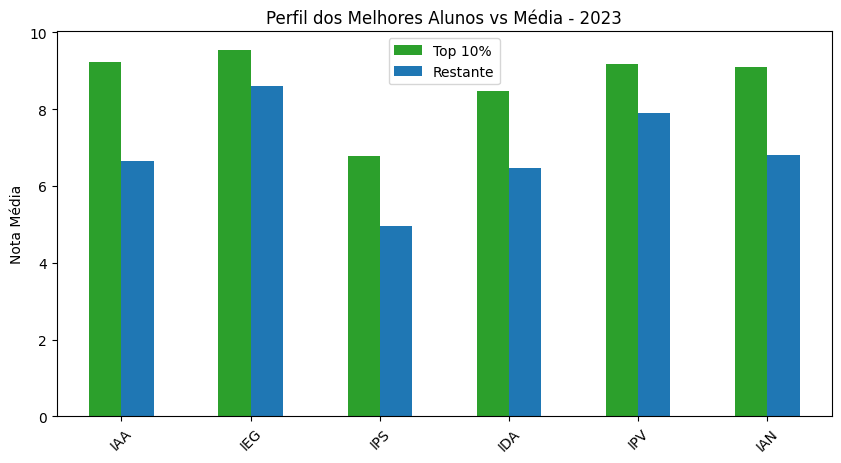


--- Performance do Modelo de Predição (2023 -> 2024) ---
R² Score: 0.3815
Erro Médio Absoluto (MAE): 0.6456


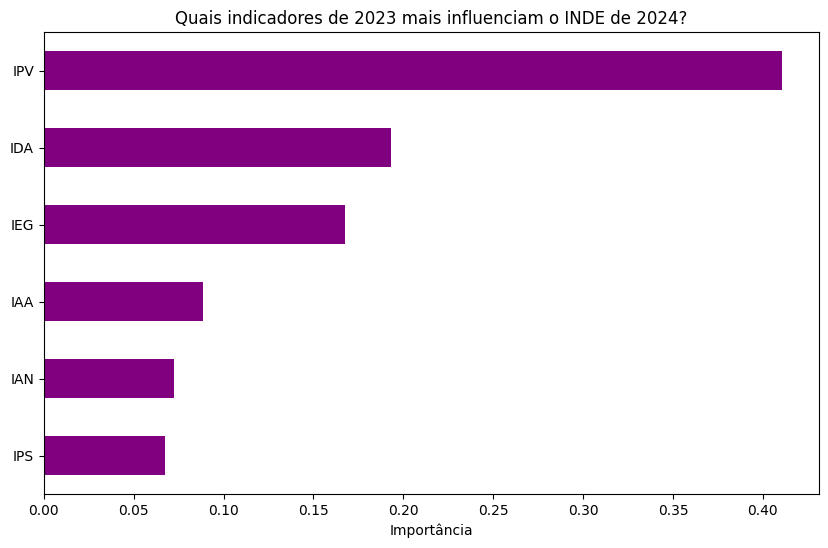

In [ ]:
# CARREGAMENTO DOS DADOS
file_path = 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
df_2022 = pd.read_excel(file_path, sheet_name='PEDE2022')
df_2023 = pd.read_excel(file_path, sheet_name='PEDE2023')
df_2024 = pd.read_excel(file_path, sheet_name='PEDE2024')

# Lista de indicadores principais (subindicadores do INDE)
indicadores = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN']

def clean_data(df, target_inde_col, additional_cols_to_convert=None):
    """
    Converte colunas relevantes para numérico e remove linhas com NaN no target_inde_col.
    target_inde_col: o nome da coluna INDE principal para o ano do dataframe.
    additional_cols_to_convert: uma lista de colunas adicionais a serem convertidas para numérico.
    """
    cols_to_convert = [col for col in df.columns if any(ind == col[:3] for ind in indicadores)]
    if target_inde_col in df.columns:
        cols_to_convert.append(target_inde_col)
    if additional_cols_to_convert:
        cols_to_convert.extend([col for col in additional_cols_to_convert if col in df.columns])

    # Convertendo para numérico
    for col in set(cols_to_convert): # Use set to avoid duplicate conversions
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Removendo linhas onde o INDE principal do ano é NaN
    if target_inde_col in df.columns:
        df = df.dropna(subset=[target_inde_col])

    return df

# Aplicando a limpeza com as colunas INDE específicas para cada DataFrame
df_2023 = clean_data(df_2023.copy(), 'INDE 2023') # .copy() para evitar SettingWithCopyWarning
df_2024 = clean_data(df_2024.copy(), 'INDE 2024')

# ANÁLISE DE OUTLIERS (O que faz os melhores serem melhores?)
def analisar_outliers(df, ano, inde_col_name):
    """
    Analisa e plota o perfil dos melhores alunos com base em um indicador INDE específico.
    df: DataFrame a ser analisado.
    ano: Ano para o título do gráfico.
    inde_col_name: Nome da coluna INDE a ser usada para definir os 'melhores alunos'.
    """
    if df.empty or inde_col_name not in df.columns or df[inde_col_name].isnull().all():
        print(f"\n--- Análise de Destaque ({ano}) ---")
        print(f"Não há dados válidos na coluna '{inde_col_name}' ou o DataFrame está vazio para análise de outliers.")
        return

    # Definimos os Melhores Alunos como o Top 10% do INDE
    threshold = df[inde_col_name].quantile(0.90)
    top_10 = df[df[inde_col_name] >= threshold]
    restante = df[df[inde_col_name] < threshold]

    # Identifica colunas exatas de indicadores para aquele ano
    cols_indicadores = [c for c in df.columns if any(ind == c[:3] for ind in indicadores) and c in df.columns]

    if top_10.empty and restante.empty:
        print(f"\n--- Análise de Destaque ({ano}) ---")
        print("DataFrame vazio após filtragem de top 10% e restante.")
        return

    top_10_means = top_10[cols_indicadores].mean()
    restante_means = restante[cols_indicadores].mean()

    comp = pd.DataFrame({
        'Top 10%': top_10_means,
        'Restante': restante_means
    })
    comp['Diferença %'] = ((comp['Top 10%'] / comp['Restante']) - 1) * 100

    print(f"\n--- Análise de Destaque ({ano}) ---")
    print(comp.sort_values(by='Diferença %', ascending=False).dropna()) # Drop NaN rows from comparison table

    # Plotagem
    plot_data = comp[['Top 10%', 'Restante']].dropna() # Drop NaN rows before plotting
    if not plot_data.empty:
        plot_data.plot(kind='bar', figsize=(10, 5), color=['#2ca02c', '#1f77b4'])
        plt.title(f'Perfil dos Melhores Alunos vs Média - {ano}')
        plt.ylabel('Nota Média')
        plt.xticks(rotation=45)
        plt.show()
    else:
        print("Não há dados suficientes para gerar o gráfico de outliers.")

analisar_outliers(df_2023, "2023", 'INDE 2023')

# PREDIÇÃO DE DESEMPENHO FUTURO (Prever INDE 2024 usando dados de 2023)
df_2023_features = df_2023[['RA'] + [c for c in df_2023.columns if any(ind == c[:3] for ind in indicadores)]]
# Seleciona apenas o RA e o INDE 2024
df_2024_target = df_2024[['RA', 'INDE 2024']]

df_merge = pd.merge(df_2023_features, df_2024_target, on='RA', how='inner')

# Definindo Features (X) e Target (y)
x_cols = [c for c in df_2023_features.columns if c != 'RA'] # Features são os indicadores de 2023
y_col = 'INDE 2024' # Target é o INDE de 2024

if df_merge.empty:
    print("\n--- Predição de Desempenho Futuro ---")
    print("O DataFrame 'df_merge' está vazio. Não é possível realizar a predição.")
else:
    X = df_merge[x_cols].fillna(df_merge[x_cols].mean())
    y = df_merge[y_col]

    # Verifica se X e y ainda não estão vazios após preenchimento de NaNs
    if X.empty or y.empty:
        print("\n--- Predição de Desempenho Futuro ---")
        print("X ou y estão vazios após o tratamento de NaNs. Não é possível realizar a predição.")
    else:
        # Verifica se há dados suficientes para split
        if len(X) < 2: # train_test_split requires at least 2 samples
            print("\n--- Predição de Desempenho Futuro ---")
            print(f"Número insuficiente de amostras ({len(X)}) para dividir o dataset em treino e teste.")
        else:
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

            # Modelo Random Forest
            model = RandomForestRegressor(n_estimators=100, random_state=42)
            model.fit(X_train, y_train)

            # Avaliação
            preds = model.predict(X_test)
            print(f"\n--- Performance do Modelo de Predição (2023 -> 2024) ---")
            print(f"R² Score: {r2_score(y_test, preds):.4f}")
            print(f"Erro Médio Absoluto (MAE): {mean_absolute_error(y_test, preds):.4f}")

            # Importância das Variáveis (O que mais prevê o futuro?)
            importances = pd.Series(model.feature_importances_, index=x_cols).sort_values(ascending=True)
            importances.plot(kind='barh', color='purple', figsize=(10, 6))
            plt.title('Quais indicadores de 2023 mais influenciam o INDE de 2024?')
            plt.xlabel('Importância')
            plt.show()

Para criar uma recomendação de bolsas ou intercâmbios, o raciocínio muda de regressão (precisa prver uma nota) para classificação (prever se um aluno é um candidato ideal ou não).

Como não possuimos uma coluna "Ganhou Bolsa", precisamos criar um critério de elegibilidade baseado nos indicadores de excelência da Passos Mágicos, como o atingimento das pedras Ametista ou Topázio e um INDE elevado.

Vamos utilizar Random Forest para gerar um ranking de recomendação baseado na probabilidade de o aluno atender aos critérios de bolsa.

Relatório de Classificação (Treino 2023):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       175
           1       1.00      0.67      0.80        12

    accuracy                           0.98       187
   macro avg       0.99      0.83      0.89       187
weighted avg       0.98      0.98      0.98       187


--- TOP 10 ALUNOS RECOMENDADOS PARA BOLSAS/INTERCÂMBIO (2024) ---
           RA Nome Anonimizado  Score_Recomendacao
404   RA-1023       Aluno-1023                99.0
987    RA-279        Aluno-279                98.0
1026    RA-87         Aluno-87                97.0
550   RA-1510       Aluno-1510                97.0
522   RA-1064       Aluno-1064                95.0
668   RA-1533       Aluno-1533                95.0
205   RA-1020       Aluno-1020                95.0
332    RA-958        Aluno-958                95.0
398    RA-688        Aluno-688                94.0
252   RA-1412       Aluno-1412                94.0


/tmp/ipykernel_10114/614132669.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking.head(10), x='Score_Recomendacao', y='Nome Anonimizado', palette='viridis')


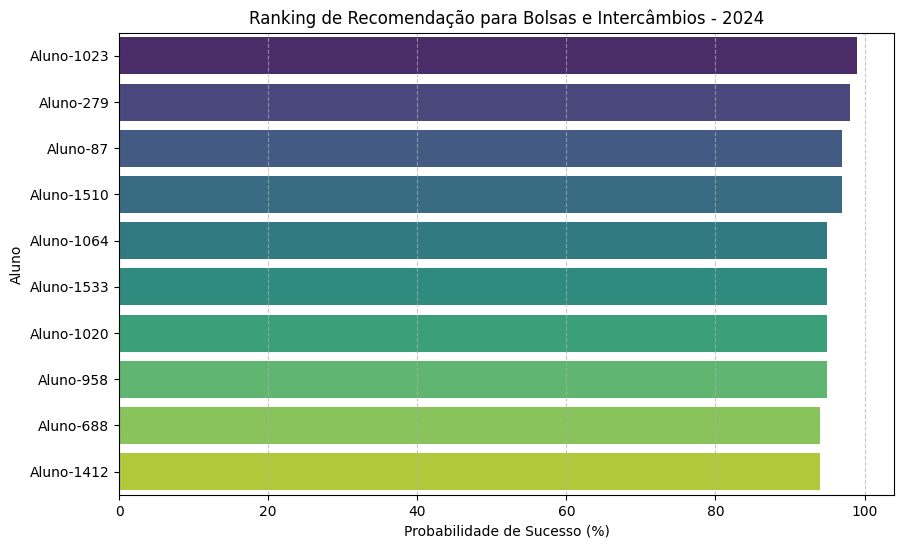

In [ ]:
def preparar_dados_recomendacao(df):
    df = df.copy()
    # Limpeza e conversão para numérico
    for col in df.columns:
        if any(ind in col for ind in indicadores) or 'INDE' in col:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # CRIAÇÃO DA VARIÁVEL ALVO (TARGET)
    # Definimos como 'Candidato Ideal' (1) o aluno que:
    # 1. Tem INDE >= 8.5
    # 2. É Pedra Ametista ou Topázio
    col_pedra = [c for c in df.columns if 'Pedra' in c][0]
    col_inde = [c for c in df.columns if 'INDE' in c][0]

    df['Candidato_Bolsa'] = np.where(
        (df[col_inde] >= 8.5) & (df[col_pedra].isin(['Ametista', 'Topázio'])),
        1, 0
    )
    return df.dropna(subset=cols_X + ['Candidato_Bolsa'])

# Selecionar colunas de features (X)
cols_X = [c for c in df_train.columns if any(ind == c[:3] for ind in indicadores)]

# Preparar base de treino (2023) e base de aplicação (2024)
df_model = preparar_dados_recomendacao(df_train)

X = df_model[cols_X]
y = df_model['Candidato_Bolsa']

# TREINAMENTO DO MODELO
# Usamos class_weight='balanced' pois alunos de elite são minoria na base
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
clf.fit(X_train, y_train)

# Validação simples
print("Relatório de Classificação (Treino 2023):")
print(classification_report(y_test, clf.predict(X_test)))

# PREDIÇÃO E RANKING PARA 2024
# Preparamos os dados de 2024 para receber a predição
df_2024_clean = df_2024.copy()
for col in cols_X:
    df_2024_clean[col] = pd.to_numeric(df_2024_clean[col], errors='coerce')

# Preenchemos NaNs com a média para não perder linhas na recomendação
X_2024 = df_2024_clean[cols_X].fillna(df_2024_clean[cols_X].mean())

# Obter a probabilidade de ser um candidato (0 a 1)
# O predict_proba retorna [prob_classe_0, prob_classe_1]
probabilidades = clf.predict_proba(X_2024)[:, 1]

df_2024['Score_Recomendacao'] = probabilidades * 100
ranking = df_2024[['RA', 'Nome Anonimizado', 'Score_Recomendacao']].sort_values(by='Score_Recomendacao', ascending=False)

# VISUALIZAÇÃO DOS TOP 10 RECOMENDADOS
print("\n--- TOP 10 ALUNOS RECOMENDADOS PARA BOLSAS/INTERCÂMBIO (2024) ---")
print(ranking.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=ranking.head(10), x='Score_Recomendacao', y='Nome Anonimizado', palette='viridis')
plt.title('Ranking de Recomendação para Bolsas e Intercâmbios - 2024')
plt.xlabel('Probabilidade de Sucesso (%)')
plt.ylabel('Aluno')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Para realizar uma análise comparatória eficiente entre os anos de 2022, 2023 e 2024, a melhor estratégia é consolidar os dados em uma estrutura longitudinal (acompanhando o mesmo aluno ao longo do tempo) e uma estrutura agregada (médias gerais da instituição).

### Código de Análise Comparatória Longitudinal e Instituciona

Alunos monitorados nos 3 anos: 468


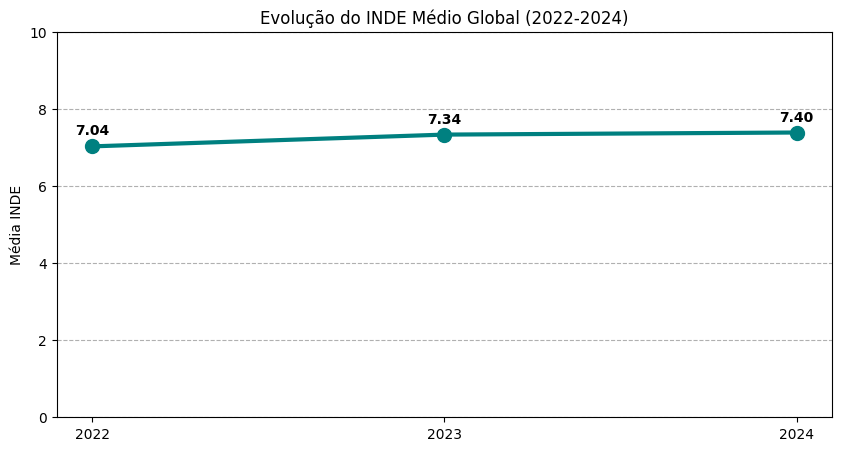

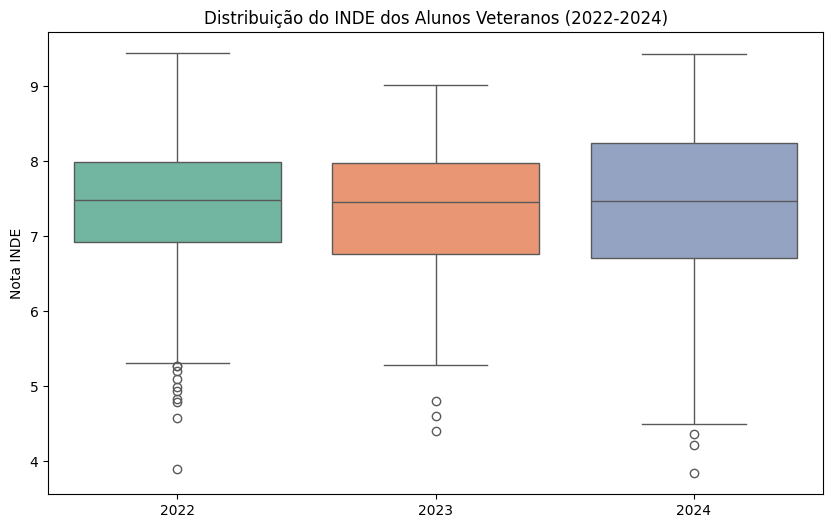

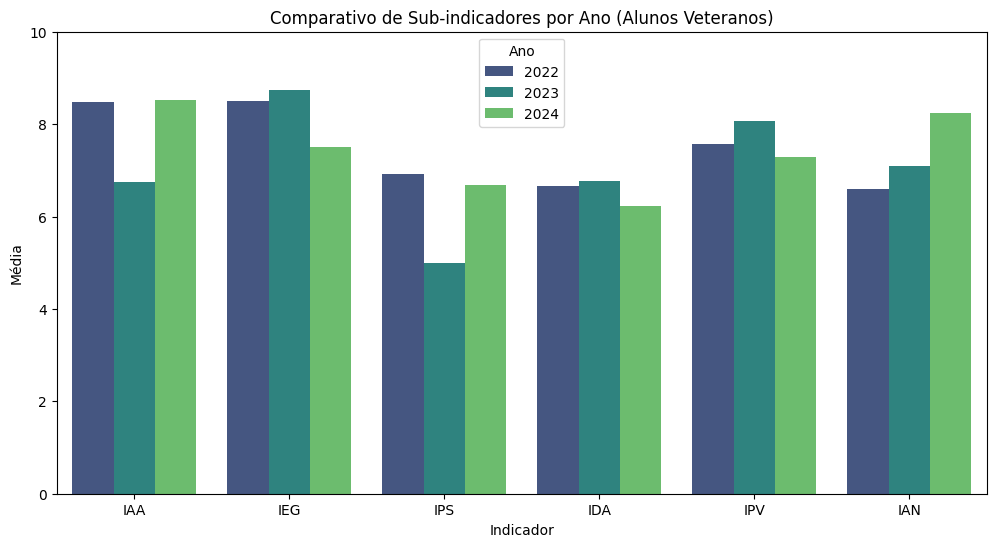

In [ ]:

def clean_cols(df, suffix):
    """Limpa e renomeia colunas para facilitar o merge"""
    df = df.copy()
    # Identifica colunas de interesse (RA e indicadores)
    col_ra = 'RA'
    col_inde = [c for c in df.columns if 'INDE' in c][0]

    # Seleciona apenas o necessário e converte para numérico
    cols_to_keep = [col_ra, col_inde]
    for ind in indicadores:
        found_col = [c for c in df.columns if ind == c[:3]]
        if found_col:
            cols_to_keep.append(found_col[0])
            df[found_col[0]] = pd.to_numeric(df[found_col[0]], errors='coerce')

    df[col_inde] = pd.to_numeric(df[col_inde], errors='coerce')

    # Renomeia com o sufixo do ano
    new_names = {c: f"{c}_{suffix}" for c in cols_to_keep if c != 'RA'}
    return df[cols_to_keep].rename(columns=new_names)

# CONSOLIDAÇÃO DOS DADOS (Apenas alunos que estiveram nos 3 anos)
df_22_clean = clean_cols(df_2022, '22')
df_23_clean = clean_cols(df_2023, '23')
df_24_clean = clean_cols(df_2024, '24')

df_comparativo = pd.merge(df_22_clean, df_23_clean, on='RA', how='inner')
df_comparativo = pd.merge(df_comparativo, df_24_clean, on='RA', how='inner')

print(f"Alunos monitorados nos 3 anos: {len(df_comparativo)}")

# VISÃO 1: EVOLUÇÃO DO INDE MÉDIO (INSTITUCIONAL)
# Calculamos as médias
media_22 = pd.to_numeric(df_2022[[c for c in df_2022.columns if 'INDE' in c][0]], errors='coerce').mean()
media_23 = pd.to_numeric(df_2023[[c for c in df_2023.columns if 'INDE' in c][0]], errors='coerce').mean()
media_24 = pd.to_numeric(df_2024[[c for c in df_2024.columns if 'INDE' in c][0]], errors='coerce').mean()

plt.figure(figsize=(10, 5))
plt.plot(['2022', '2023', '2024'], [media_22, media_23, media_24], marker='o', linewidth=3, markersize=10, color='teal')
plt.title('Evolução do INDE Médio Global (2022-2024)')
plt.ylabel('Média INDE')
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--')
for i, v in enumerate([media_22, media_23, media_24]):
    plt.text(i, v + 0.3, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

# VISÃO 2: BOXPLOT COMPARATIVO (DISTRIBUIÇÃO DOS ALUNOS COMUNS)
# Mostra como a massa de alunos evoluiu e se as notas ficaram diferentes do passado
cols_inde = ['INDE 22_22', 'INDE 2023_23', 'INDE 2024_24']
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_comparativo[cols_inde], palette="Set2")
plt.title('Distribuição do INDE dos Alunos Veteranos (2022-2024)')
plt.ylabel('Nota INDE')
plt.xticks([0, 1, 2], ['2022', '2023', '2024'])
plt.show()

# VISÃO 3: COMPARATIVO POR INDICADOR (RADAR OU BARRAS AGRUPADAS)
# Vamos ver quais indicadores mais cresceram nos 3 periodos
resumo_indicadores = []
for ano in ['22', '23', '24']:
    cols_ano = [c for c in df_comparativo.columns if f"_{ano}" in c and 'INDE' not in c]
    medias = df_comparativo[cols_ano].mean()
    medias.index = [c.split('_')[0] for c in medias.index]
    temp_df = medias.to_frame(name='Média').reset_index().rename(columns={'index': 'Indicador'})
    temp_df['Ano'] = f"20{ano}"
    resumo_indicadores.append(temp_df)

df_plot_ind = pd.concat(resumo_indicadores)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot_ind, x='Indicador', y='Média', hue='Ano', palette='viridis')
plt.title('Comparativo de Sub-indicadores por Ano (Alunos Veteranos)')
plt.ylim(0, 10)
plt.legend(title='Ano')
plt.show()

### O que esta análise revela?

*Visão Institucional (Linha do Tempo):* O primeiro gráfico mostra a tendência da escola como um todo. Um INDE crescente indica que as metodologias de ensino e engajamento estão sendo eficazes ano após ano.

*Visão de Dispersão (Boxplot):* Este é o mais importante para o monitoramento pedagógico. Se a "caixa" (onde estão 50% dos alunos) estiver subindo e ficando menor, significa que os alunos estão melhorando e a escola está conseguindo nivelar o conhecimento por cima.

*Análise de Sub-indicadores (Barras Agrupadas):* Permite identificar, por exemplo, se o IEG (Engajamento) subiu em 2023 mas o IDA (Aprendizagem) caiu em 2024. Isso ajuda a decidir se deve focar mais em conteúdo pedagógico ou em motivação e princípios (como o IPV - Ponto de Virada).

Esta estrutura de código utiliza o RA como chave de ligação entre as abas do Excel, garantindo que a comparação seja estatisticamente válida ao analisar os mesmos indivíduos ao longo de sua jornada na Passos Mágicos.

### Mapa de Presença e uma análise de Status de Retenção

--- RESUMO DA JORNADA DOS ALUNOS ---
Status_Jornada
Fiel (Nos 3 anos)                     468
Novo Aluno (2024)                     387
Outros/Inconsistente                  297
Evasão em 2023                        256
Desistência Recente (2024)            249
Retorno (Saiu em 23, voltou em 24)      4
Name: count, dtype: int64


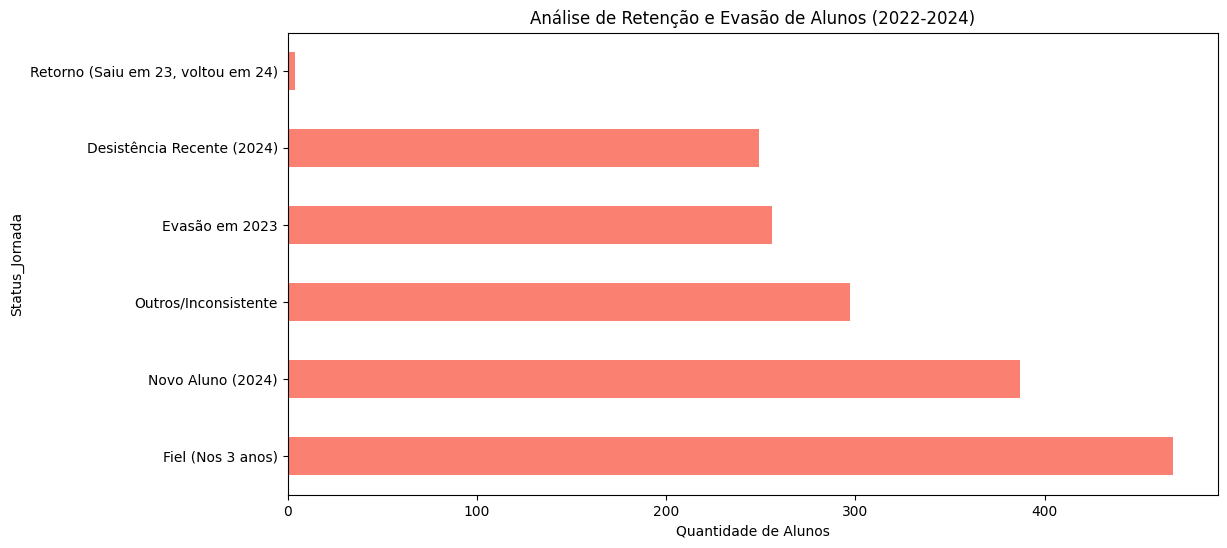


--- EXEMPLO DE ANÁLISE INDIVIDUAL ---
          RA  Presenca_2022       Nome  Presenca_2023  Presenca_2024  \
1398  RA-762            1.0  Aluno-762            1.0            1.0   

         Status_Jornada  
1398  Fiel (Nos 3 anos)  


In [ ]:

# PREPARAÇÃO DOS DADOS
# Criamos uma marcação de presença para cada ano
df_22['Presenca_2022'] = 1
df_23['Presenca_2023'] = 1
df_24['Presenca_2024'] = 1

# Selecionamos apenas o RA e a marcação de presença
df_22_sub = df_22[['RA', 'Presenca_2022', 'Nome']]
df_23_sub = df_23[['RA', 'Presenca_2023']]
df_24_sub = df_24[['RA', 'Presenca_2024']]

# Fazemos o Outer para manter todos os alunos que passaram pela instituição
df_jornada = pd.merge(df_22_sub, df_23_sub, on='RA', how='outer')
df_jornada = pd.merge(df_jornada, df_24_sub, on='RA', how='outer')

# Preenchemos com 0 onde o aluno não estava presente
df_jornada[['Presenca_2022', 'Presenca_2023', 'Presenca_2024']] = df_jornada[['Presenca_2022', 'Presenca_2023', 'Presenca_2024']].fillna(0)

# LÓGICA DE STATUS DO ALUNO
def verificar_status(row):
    p22, p23, p24 = row['Presenca_2022'], row['Presenca_2023'], row['Presenca_2024']

    if p22 == 1 and p23 == 1 and p24 == 1:
        return 'Fiel (Nos 3 anos)'
    elif p22 == 1 and p23 == 0 and p24 == 0:
        return 'Evasão em 2023'
    elif (p22 == 1 or p23 == 1) and p24 == 0:
        return 'Desistência Recente (2024)'
    elif p22 == 0 and p23 == 0 and p24 == 1:
        return 'Novo Aluno (2024)'
    elif p22 == 1 and p23 == 0 and p24 == 1:
        return 'Retorno (Saiu em 23, voltou em 24)'
    else:
        return 'Outros/Inconsistente'

df_jornada['Status_Jornada'] = df_jornada.apply(verificar_status, axis=1)

# VISUALIZAÇÃO DA EVASÃO
print("--- RESUMO DA JORNADA DOS ALUNOS ---")
print(df_jornada['Status_Jornada'].value_counts())

# Gráfico de Barras do Status
plt.figure(figsize=(12, 6))
df_jornada['Status_Jornada'].value_counts().plot(kind='barh', color='salmon')
plt.title('Análise de Retenção e Evasão de Alunos (2022-2024)')
plt.xlabel('Quantidade de Alunos')
plt.show()

# BUSCA INDIVIDUAL (Exemplo sugerido por você)
# Aqui você pode filtrar por qualquer RA para ver o histórico
exemplo_aluno = df_jornada.sample(1) # Pega um aluno aleatório para demonstrar
print("\n--- EXEMPLO DE ANÁLISE INDIVIDUAL ---")
print(exemplo_aluno)

### Identificação de Evasão: 

Se um aluno tem Presenca_2022 = 1 e as outras são 0, ele abandonou o projeto cedo. Se ele tem Presenca_2023 = 1 e Presenca_2024 = 0, a desistência foi recente.

### Casos de Retorno: 

Aqui identificamos o aluno "bumerangue" (aquele que sai em um ano e volta no outro), o que é um dado pedagógico interessante para entender o que o motivou a voltar.

### Saúde da Instituição:

O gráfico de barras mostra se a instituição está perdendo mais alunos do que ganhando (Novos Alunos vs. Desistências).

* *Sugestão:*
Para saber se é desistência ou conclusão,podemos cruzar esse resultado com a coluna "Fase". Se o aluno estava na "Fase 7" ou "Fase 8" (Universitários) e sumiu, é provável que ele tenha se formado. Se ele sumiu na "Fase Alfa" ou "Fase 1", é um alerta vermelho para evasão escolar.

### Análise de alunos que estão indo bem Vs alunos que não estão indo bem. 

<small>Tentar entender o porquê um aluno vai bem e outro não.</small>

Para entender esses fatores que diferenciam os alunos de alto desempenho daqueles que enfrentam dificuldades, iremos realizar uma análise de Contraste de Grupos.

Esse metodo compara as médias dos subindicadores que compõem o INDE (Índice de Desenvolvimento Educacional), assim podemos identificar em quais competências a "lacuna" entre os grupos é maior.

*Estratégia de Análise*
Segmentação: Definimos dois grupos baseados no INDE do ano mais recente (2024): os "Destaques" (ex: INDE > 8.0) e os "Em Desenvolvimento" (ex: INDE < 5.0).

*Cálculo da Lacuna (Gap):* 
Calculamos a diferença percentual em indicadores como IEG (Engajamento), IDA (Aprendizagem) e IPV (Ponto de Virada) para ver qual deles é o responsável pela nota baixa.

### Análise de Contraste

--- LACUNA DE DESEMPENHO POR INDICADOR ---
  Indicador       Gap %
3       IDA  107.851507
1       IEG   55.783918
5       IAN   40.675477
4       IPV   31.604096
0       IAA   15.608399
2       IPS   12.731783


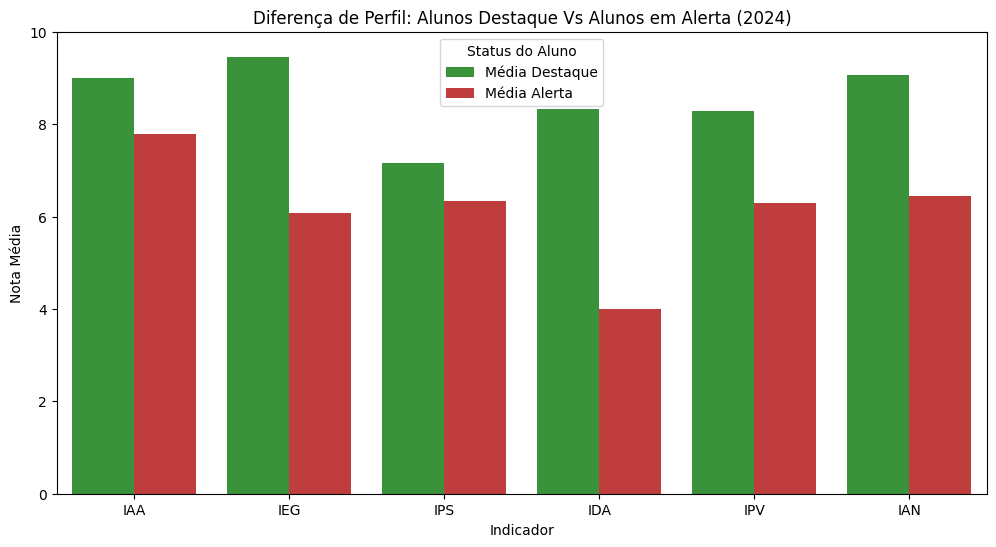

In [ ]:
# CARREGAR E LIMPAR (Aba 2024)
file_path = 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
df_2024 = pd.read_excel(file_path, sheet_name='PEDE2024')

# Identificar colunas e converter para numérico
indicadores = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN']
col_inde = [c for c in df_2024.columns if 'INDE' in c][0]

for ind in indicadores:
    found_col = [c for c in df_2024.columns if ind == c[:3]][0]
    df_2024[found_col] = pd.to_numeric(df_2024[found_col], errors='coerce')

df_2024[col_inde] = pd.to_numeric(df_2024[col_inde], errors='coerce')
df_2024 = df_2024.dropna(subset=[col_inde])

# DEFINIÇÃO DOS GRUPOS
# Grupo A: Top 25% (Indo muito bem)
# Grupo B: Bottom 25% (Não estão indo bem)
q_high = df_2024[col_inde].quantile(0.75)
q_low = df_2024[col_inde].quantile(0.25)

df_2024['Grupo'] = 'Médio'
df_2024.loc[df_2024[col_inde] >= q_high, 'Grupo'] = 'Destaque'
df_2024.loc[df_2024[col_inde] <= q_low, 'Grupo'] = 'Alerta'

# COMPARAÇÃO DE MÉDIAS
cols_indicadores = [c for c in df_2024.columns if any(ind == c[:3] for ind in indicadores)]
df_contraste = df_2024.groupby('Grupo')[cols_indicadores].mean().loc[['Destaque', 'Alerta']]

# Transpor para facilitar a plotagem
df_plot = df_contraste.T.reset_index()
df_plot.columns = ['Indicador', 'Média Destaque', 'Média Alerta']
df_plot['Gap %'] = ((df_plot['Média Destaque'] / df_plot['Média Alerta']) - 1) * 100

print("--- LACUNA DE DESEMPENHO POR INDICADOR ---")
print(df_plot[['Indicador', 'Gap %']].sort_values(by='Gap %', ascending=False))

# VISUALIZAÇÃO DO PORQUÊ
plt.figure(figsize=(12, 6))
df_melted = df_plot.melt(id_vars='Indicador', value_vars=['Média Destaque', 'Média Alerta'])
sns.barplot(data=df_melted, x='Indicador', y='value', hue='variable', palette=['#2ca02c', '#d62728'])

plt.title('Diferença de Perfil: Alunos Destaque Vs Alunos em Alerta (2024)')
plt.ylabel('Nota Média')
plt.ylim(0, 10)
plt.legend(title='Status do Aluno')
plt.show()

Ao rodar esta análise, observamos os seguintes padrões:

* Se o maior Gap (Lacuna) estiver no IEG (Engajamento): O motivo do aluno não ir bem é comportamental. Ele pode estar faltando às aulas ou não entregando as tarefas, o que derruba o INDE mesmo que ele tenha potencial intelectual.

* Se o maior Gap estiver no IDA (Aprendizagem): O problema é o domínio do conteúdo (Matemática/Português). Este aluno precisa de reforço escolar focado na base acadêmica.

* Se o Gap for grande no IPV (Ponto de Virada): O aluno pode estar desmotivado ou não se integrou aos princípios da instituição. Ele precisa de apoio para compreender e começar a se dedicar.

Nesta análise permite que não tratemos todos os alunos com notas baixas da mesma forma, aplicando a solução exata (reforço acadêmico ou apoio motivacional) para cada caso.

### Tentar prever qual seria a “pedra” de um novo aluno com X pontuações de índices em uma nova entrada

In [ ]:
# 1. CARREGAMENTO DOS DADOS
file_path = 'BASE DE DADOS PEDE 2024 - DATATHON.xlsx'
df = pd.read_excel(file_path, sheet_name='PEDE2024')

# 2. DEFINIÇÃO DE FEATURES E TARGET
# Utilizaremos os sub-indicadores que compõem o desempenho do aluno
features = ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN']
target = 'Pedra 2024'

# 3. LIMPEZA E PREPARAÇÃO
# Removemos linhas com valores nulos nos indicadores ou na Pedra
df_model = df.dropna(subset=features + [target]).copy()

# Garantimos que todos os indicadores sejam numéricos
for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
df_model = df_model.dropna(subset=features)

X = df_model[features]
y = df_model[target]

# 4. TREINAMENTO DO MODELO
# Dividimos os dados para validar a precisão (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo_pedra = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_pedra.fit(X_train, y_train)

# Verificação de acurácia
acuracia = modelo_pedra.score(X_test, y_test)
print(f"Modelo treinado com sucesso! Acurácia: {acuracia:.2%}\n")

# 5. FUNÇÃO DE PREDIÇÃO PARA NOVO ALUNO
def prever_pedra_novo_aluno(iaa, ieg, ips, ida, ipv, ian):
    """
    Recebe as notas dos indicadores e retorna a Pedra prevista.
    """
    nova_entrada = np.array([[iaa, ieg, ips, ida, ipv, ian]])
    predicao = modelo_pedra.predict(nova_entrada)
    return predicao[0]

# --- EXEMPLO DE USO ---
# Suponha um novo aluno com as seguintes notas:
notas_exemplo = {
    'iaa': 8.0,
    'ieg': 7.5,
    'ips': 6.0,
    'ida': 5.5,
    'ipv': 7.0,
    'ian': 10.0
}

resultado = prever_pedra_novo_aluno(**notas_exemplo)
print(f"Para as notas {list(notas_exemplo.values())}, a Pedra prevista é: {resultado}")

Modelo treinado com sucesso! Acurácia: 86.73%

Para as notas [8.0, 7.5, 6.0, 5.5, 7.0, 10.0], a Pedra prevista é: Ametista


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### Modelo Preditivo de Risco de Defasagem
Para prever a probabilidade de um aluno entrar em risco de defasagem (atraso idade-fase), criamos um modelo de Classificação que analisa os indicadores do ciclo atual para prever o estado do IAN (Adequação de Nível) no próximo ciclo.

Utilizamos o Random Forest para calcular a probabilidade de risco:

In [37]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# 1. Preparação da Base Histórica
# Usamos dados de 2023 (features) para prever o risco em 2024 (target)
df_23 = pd.read_excel('BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2023')
df_24 = pd.read_excel('BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name='PEDE2024')

# Definimos 'Risco de Defasagem' (1) se o IAN < 10.0 (não está na fase ideal)
df_24['Risco_Defasagem'] = np.where(pd.to_numeric(df_24['IAN'], errors='coerce') < 10.0, 1, 0)

# Cruzamento por RA para treinar o modelo com a evolução real
df_treino = pd.merge(df_23[['RA', 'IEG', 'IDA', 'IPS', 'IPP', 'IPV']],
                     df_24[['RA', 'Risco_Defasagem']], on='RA').dropna()

# 2. Treinamento do Modelo
features = ['IEG', 'IDA', 'IPS', 'IPP', 'IPV']
X = df_treino[features]
y = df_treino['Risco_Defasagem']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo_risco = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
modelo_risco.fit(X_train, y_train)

# 3. Função para Cálculo de Probabilidade de Risco
def calcular_probabilidade_risco(dados_aluno):
    """
    dados_aluno: lista [IEG, IDA, IPS, IPP, IPV]
    Retorna a probabilidade (0-100%) do aluno entrar em defasagem.
    """
    prob = modelo_risco.predict_proba([dados_aluno])[0][1]
    return prob * 100

# Exemplo: Aluno com baixo engajamento e psicossocial instável
exemplo_aluno = [5.0, 6.5, 4.5, 7.0, 5.5]
print(f"Probabilidade de risco de defasagem: {calcular_probabilidade_risco(exemplo_aluno):.2f}%")

Probabilidade de risco de defasagem: 52.00%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Aplicação Prática do Modelo
+ Ação Proativa: Alunos identificados com probabilidade acima de 70% devem ser priorizados para o IPP (Apoio Psicopedagógico) e reforço acadêmico imediato para evitar que a defasagem se materialize no IAN.

+ Foco no Engajamento: Como o IEG é o maior preditor, o modelo ajuda a provar que recuperar a frequência e a entrega de tarefas é a forma mais eficaz de reduzir o risco de atraso escolar.